In [1]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt
from datasets import *
from sklearn.metrics import recall_score, f1_score, roc_auc_score, accuracy_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
import shap
import reload_shap_plot

In [2]:
# --------------------------
# 新增方法：基于阈值的检测方法 (Threshold Detector)
# 该方法基于每个样本展平后特征的均值是否超过预设阈值来判断异常
class ThresholdDetector:
    def __init__(self, feature_len, channel=1, threshold=None):
        """
        feature_len: 每个通道的特征数量
        channel: 输入通道数
        threshold: 阈值。如果为 None，则在 fit 时根据训练数据自适应设定 (mean + std)
        """
        self.num_features = channel * feature_len
        self.threshold = threshold

    def fit(self, x, y=None):
        """
        x: numpy 数组，形状为 (n_samples, channel, feature_len)
        y: 可选标签，未使用
        若未指定阈值，则根据训练数据计算每个样本展平后均值的整体均值与标准差，阈值 = 均值 + 标准差
        """
        n_samples = x.shape[0]
        x_flat = x.reshape(n_samples, -1)
        self.normal_means = np.mean(x_flat, axis=0) # [num_features]
        self.normal_std = np.std(x_flat, axis=0)    # [num_features]
        if self.threshold is None:
            self.threshold = np.mean(self.normal_std)

    def predict(self, x):
        """
        x: numpy 数组，形状为 (n_samples, channel, feature_len)
        返回: numpy 数组，预测结果 (0 or 1)，1 表示样本均值超过阈值 (异常)
        """
        n_samples = x.shape[0]
        x_flat = x.reshape(n_samples, -1)
        
        diff = np.abs(x_flat - self.normal_means)
        predictions = (np.max(diff - self.normal_std, axis=1) > self.threshold).astype(int)
        return predictions
    
    def predict_proba(self, x):
        n_samples = x.shape[0]
        x_flat = x.reshape(n_samples, -1)
        
        # Convert PyTorch tensor to NumPy array
        if isinstance(x_flat, torch.Tensor):
            x_flat = x_flat.numpy()
        
        sample_means = np.mean(x_flat, axis=1)
        proba = (np.abs(x_flat - self.normal_means)-self.normal_std) / self.threshold
        proba = np.mean(proba, axis=1)
        proba = np.clip(proba, 0, 1)
        return np.vstack([1 - proba, proba]).T

In [3]:
dataset = BinaryDataset('Node123_loop')
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(20))
feature_names = [f'Bus {i+1}' for i in range(1, dataset.n_buses + 1)]

In [4]:
# model = ThresholdDetector(feature_len=dataset.n_buses, channel=1, threshold=0.242)
model = ThresholdDetector(feature_len=dataset.n_buses, channel=1, threshold=0.00001)

In [5]:
# model.fit(train_dataset.dataset.data.numpy(), train_dataset.dataset.labels)
normal_dataset = dataset.data_df.values
outage_dataset = dataset.data_outage_df.values
model.fit(normal_dataset, np.zeros(normal_dataset.shape[0]))

In [6]:
# Get predictions
y_true = test_dataset.dataset.labels[test_dataset.indices]
y_pred = model.predict(test_dataset.dataset.data[test_dataset.indices].numpy())
y_proba = model.predict_proba(test_dataset.dataset.data[test_dataset.indices])[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_proba)

# Print metrics
print(f'Accuracy: {accuracy}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print(f'AUC: {auc}')

Accuracy: 0.6925
Recall: 0.965
F1 Score: 0.7583497053045186
AUC: 0.5175000000000001


In [7]:
# for threshold in np.arange(0.0, 1.5, 0.0005):
#     model = ThresholdDetector(feature_len=dataset.n_buses, channel=1, threshold=threshold)
#     model.fit(normal_dataset, np.zeros(normal_dataset.shape[0]))
    
#     # Get predictions
#     # y_true = test_dataset.dataset.labels[test_dataset.indices]
#     # y_pred = model.predict(test_dataset.dataset.data[test_dataset.indices].numpy())
#     # y_proba = model.predict_proba(test_dataset.dataset.data[test_dataset.indices])[:, 1]

#     y_true = np.ones(outage_dataset.shape[0])
#     y_pred = model.predict(outage_dataset)

#     # Calculate metrics
#     accuracy = accuracy_score(y_true, y_pred)
#     recall = recall_score(y_true, y_pred)
#     f1 = f1_score(y_true, y_pred)

#     # Print metrics
#     # Record the largest F1 score and corresponding metrics
#     if 'best_f1' not in locals():
#         best_f1 = 0
#         best_metrics = {}

#     if f1 > best_f1:
#         best_f1 = f1
#         best_metrics = {
#             'threshold': threshold,
#             'accuracy': accuracy,
#             'recall': recall,
#         }

# # Print the best metrics
# print(f"Best F1: {best_f1}")
# print(f"Threshold: {best_metrics['threshold']}")
# print(f"Accuracy: {best_metrics['accuracy']}")
# print(f"Recall: {best_metrics['recall']}")
    

In [8]:
diff = y_true.squeeze().numpy() - y_pred

num_zeros = (diff == 0).sum().item()
print(f'Number of zeros in y_true: {num_zeros}')

Number of zeros in y_true: 277


In [9]:
y_true.shape

torch.Size([400, 1])

# Explain

In [10]:
label_1_samples = []
label_0_samples = []
for data, label in train_dataset:
    if label.item() == 1:  # Filter label 1 samples
        label_1_samples.append(data)  # Convert to NumPy for SHAP
    else: 
        label_0_samples.append(data)

# Convert to NumPy array for SHAP compatibility
label_0_samples = np.array(label_0_samples)
label_1_samples = np.array(label_1_samples)

print(label_0_samples.shape)
print(label_1_samples.shape)

(800, 1, 122)
(800, 1, 122)


In [11]:
# Compute mean background from normal (label 0) samples
background_mean = label_0_samples.mean(0)  # Compute mean across samples
# background_mean = torch.tensor(np.zeros_like(background_mean)+0.1, dtype=torch.float32)  # Use zero mean as background

# Ensure at least (n_buses + 1) samples
n_buses = background_mean.shape[-1]
num_background_samples = n_buses + 1  # Ensure SHAP has enough samples

# Convert to NumPy for SHAP
background = background_mean

""" Check this line of code """
background = np.tile(background, (2, 1))  # Expand background size *2

background.shape

(2, 122)

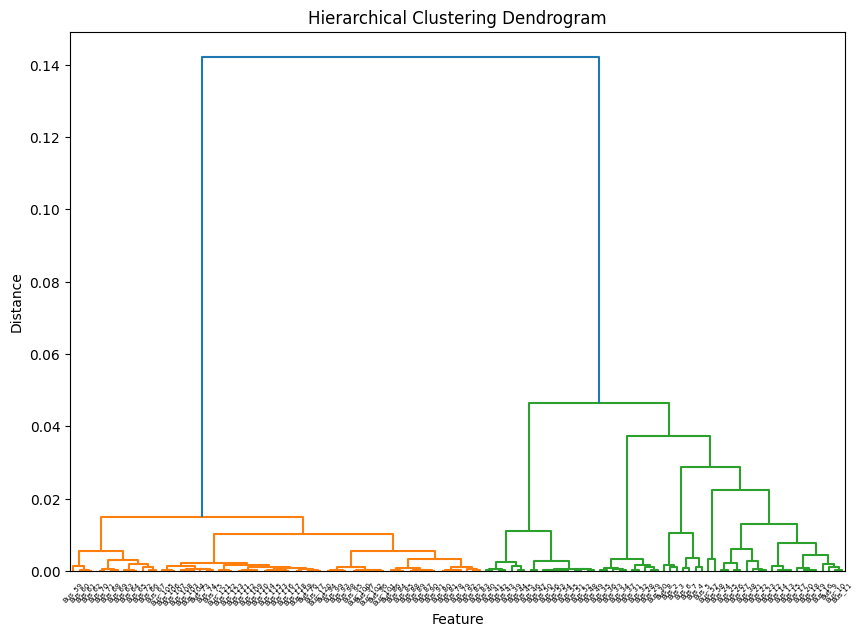

In [12]:
def get_matrix_from_data(data_normal, data_outage):
    # # Combine the two datasets
    # combined_data = pd.concat([data_normal, data_outage])
    combined_data = data_normal
    # combined_data = data_outage

    # Compute the correlation matrix
    corr_matrix = combined_data.corr()

    # Convert the correlation matrix to a distance matrix
    distance_matrix = 1 - corr_matrix

    # Perform hierarchical clustering
    Z = linkage(squareform(distance_matrix), method='average')
    return Z, corr_matrix

Z, corr_matrix = get_matrix_from_data(dataset.data_df, dataset.data_outage_df)

# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(Z, labels=corr_matrix.columns, leaf_rotation=45)
# dendrogram(Z, leaf_rotation=45)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Feature')
plt.ylabel('Distance')
plt.show()

In [13]:
instance = label_1_samples[0]
instance.shape

(1, 122)

In [14]:
def model_wrapper(x):
    # Get prediction
    return model.predict_proba(x)[:, 1]

In [15]:
# Initialize SHAP Explainer
masker = shap.maskers.Partition(background)
masker.clustering = Z  # 强制使用你的 partition_tree
explainer = shap.PartitionExplainer(model_wrapper, masker, feature_names=feature_names)

In [16]:
shap_values = explainer(label_1_samples.squeeze())

PartitionExplainer explainer: 801it [00:20, 20.30it/s]                         


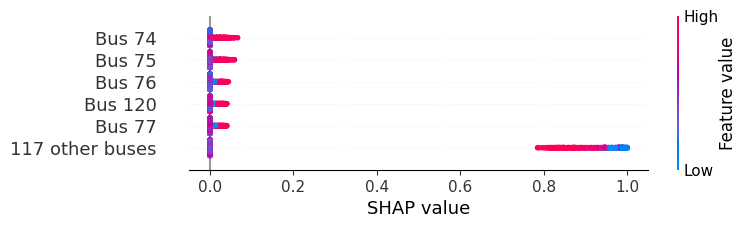

In [17]:
shap.plots.beeswarm(shap_values, max_display=6, plot_size=(7.4, 2))

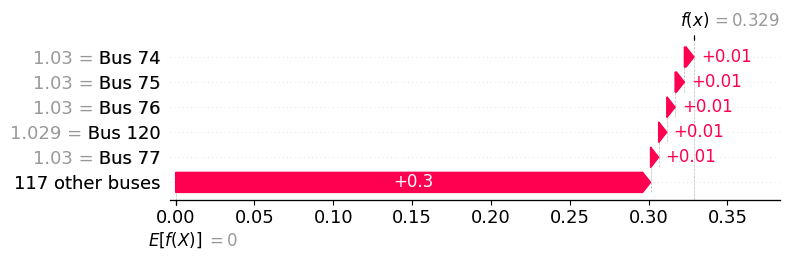

In [18]:
shap.plots.waterfall(shap_values.mean(0), show=False)
plt.tight_layout()
plt.show()

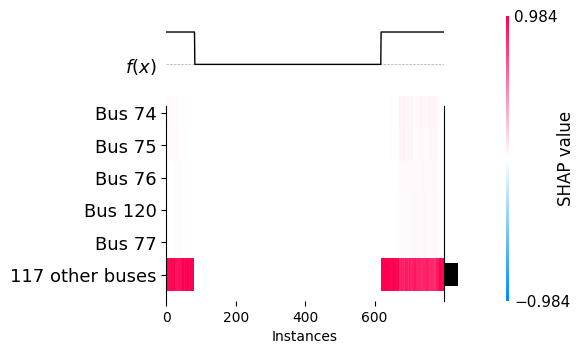

<Axes: xlabel='Instances'>

In [19]:
shap.plots.heatmap(shap_values, max_display=6)

---

In [20]:
explainer = shap.Explainer(model_wrapper, background, feature_names=feature_names)

In [21]:
shap_values = explainer(label_1_samples.squeeze())

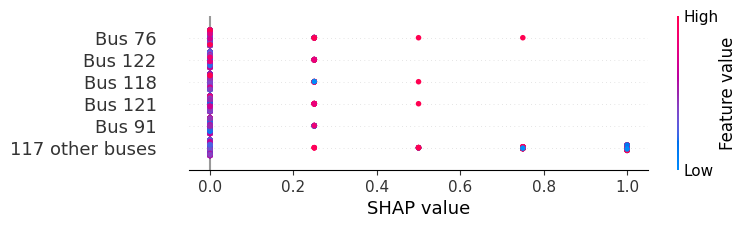

In [22]:
shap.plots.beeswarm(shap_values, max_display=6, plot_size=(7.4, 2))

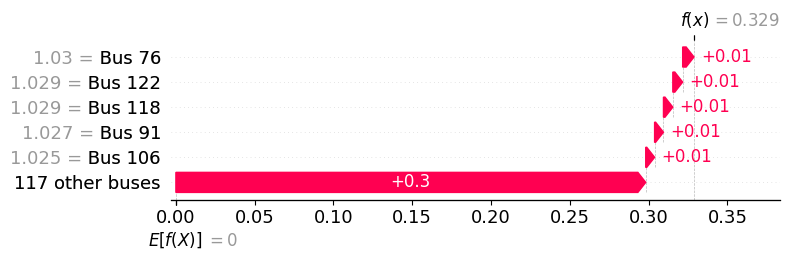

In [23]:
shap.plots.waterfall(shap_values.mean(0), show=False)
plt.tight_layout()
plt.show()

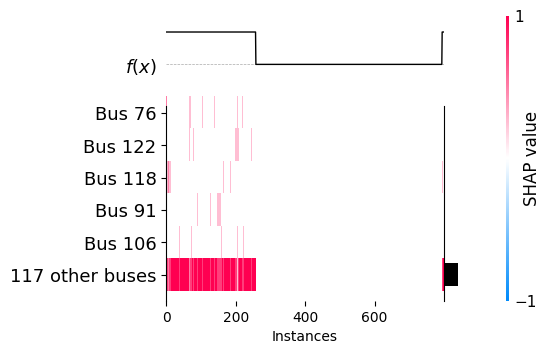

<Axes: xlabel='Instances'>

In [24]:
shap.plots.heatmap(shap_values, max_display=6)